<a href="https://colab.research.google.com/github/priyanka8993/HGT/blob/main/Dynamic_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
!pip -q install xgboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from scipy.optimize import minimize, differential_evolution

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [3]:
dates = pd.date_range(
    start="2024-01-01",
    end="2025-12-31",
    freq="D"
)

skus = ["SKU_A", "SKU_B", "SKU_C"]
regions = ["North", "South", "West"]

data = []

for date in dates:
    for sku in skus:
        for region in regions:

            # Base price by SKU
            base_price = {
                "SKU_A": 100,
                "SKU_B": 150,
                "SKU_C": 200
            }[sku]

            # Regional price variation
            region_factor = {
                "North": 1.00,
                "South": 0.95,
                "West": 1.05
            }[region]

            price = base_price * region_factor * np.random.uniform(0.90, 1.10)

            # Competitor price
            competitor_price = price * np.random.uniform(0.90, 1.10)

            # Promotion
            promotion = np.random.choice(
                [0, 1],
                p=[0.75, 0.25]
            )

            # Holiday
            holiday = int(
                date.month in [10, 11, 12] and
                date.day in range(1, 6)
            )

            # Seasonality
            seasonal_factor = (
                1
                + 0.15 * np.sin(2 * np.pi * date.dayofyear / 365)
            )

            # Weekend effect
            weekend_factor = 1.15 if date.dayofweek >= 5 else 1.0

            # Marketing
            marketing_spend = np.random.uniform(100, 1000)

            # Temperature
            temperature = (
                25
                + 10 * np.sin(2 * np.pi * date.dayofyear / 365)
                + np.random.normal(0, 3)
            )

            # Inventory
            inventory = np.random.randint(50, 500)

            # Base demand
            base_demand = {
                "SKU_A": 80,
                "SKU_B": 60,
                "SKU_C": 40
            }[sku]

            # Price elasticity
            elasticity = {
                "SKU_A": -1.5,
                "SKU_B": -1.2,
                "SKU_C": -1.8
            }[sku]

            # Price effect
            price_effect = (
                price / base_price
            ) ** elasticity

            # Competitor effect
            competitor_effect = (
                competitor_price / price
            ) ** 0.8

            # Promotion effect
            promotion_effect = 1.30 if promotion else 1.0

            # Marketing effect
            marketing_effect = 1 + 0.0003 * marketing_spend

            # Random noise
            noise = np.random.normal(0, 5)

            demand = (
                base_demand
                * seasonal_factor
                * weekend_factor
                * price_effect
                * competitor_effect
                * promotion_effect
                * marketing_effect
                * (1 + 0.15 * holiday)
                + noise
            )

            # Inventory constraint
            demand = min(max(demand, 0), inventory)

            data.append([
                date,
                sku,
                region,
                price,
                competitor_price,
                promotion,
                holiday,
                marketing_spend,
                temperature,
                inventory,
                demand
            ])

df = pd.DataFrame(
    data,
    columns=[
        "date",
        "sku",
        "region",
        "price",
        "competitor_price",
        "promotion",
        "holiday",
        "marketing_spend",
        "temperature",
        "inventory",
        "units_sold"
    ]
)

df.head()

,date,sku,region,price,competitor_price,promotion,holiday,marketing_spend,temperature,inventory,units_sold
0,2024-01-01,SKU_A,North,97.490802,106.278902,0,0,638.792636,24.469673,380,105.217996
1,2024-01-01,SKU_A,South,94.225729,91.091943,0,0,685.799626,25.411629,463,102.112430
2,2024-01-01,SKU_A,West,98.959121,92.661857,0,0,373.818019,17.334487,98,90.721240
3,2024-01-01,SKU_B,North,150.743240,147.724183,0,0,976.379967,24.419002,495,75.254601
4,2024-01-01,SKU_B,South,133.940703,134.322017,0,0,141.805371,21.719153,216,73.884158


In [4]:
df.shape

(6579, 11)

In [5]:
df.columns

Index(['date', 'sku', 'region', 'price', 'competitor_price', 'promotion',
       'holiday', 'marketing_spend', 'temperature', 'inventory', 'units_sold'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6579 entries, 0 to 6578
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              6579 non-null   datetime64[ns]
 1   sku               6579 non-null   object        
 2   region            6579 non-null   object        
 3   price             6579 non-null   float64       
 4   competitor_price  6579 non-null   float64       
 5   promotion         6579 non-null   int64         
 6   holiday           6579 non-null   int64         
 7   marketing_spend   6579 non-null   float64       
 8   temperature       6579 non-null   float64       
 9   inventory         6579 non-null   int64         
 10  units_sold        6579 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(3), object(2)
memory usage: 565.5+ KB


In [19]:
df.describe()

,date,price,competitor_price,promotion,holiday,marketing_spend,temperature,inventory,units_sold
count,6579,6579.000000,6579.000000,6579.000000,6579.000000,6579.000000,6579.000000,6579.000000,6579.000000
mean,2024-12-31 00:00:00,149.913866,149.932537,0.245782,0.041040,548.048594,25.044792,275.224046,77.490557
min,2024-01-01 00:00:00,85.507629,78.260382,0.000000,0.000000,100.106780,5.738434,50.000000,19.150777
25%,2024-07-01 00:00:00,105.075970,106.431231,0.000000,0.000000,318.686668,18.438278,162.000000,56.926807
50%,2024-12-31 00:00:00,150.136740,149.790823,0.000000,0.000000,546.177366,24.951776,276.000000,74.218143
75%,2025-07-02 00:00:00,189.408922,186.641206,0.000000,0.000000,773.755055,31.654199,387.000000,94.395184
max,2025-12-31 00:00:00,230.971283,253.545150,1.000000,1.000000,999.824630,43.216886,499.000000,193.189566
std,NaN,42.162988,43.117375,0.430583,0.198397,261.291934,7.693149,129.838775,26.825240


In [20]:
df.duplicated().sum()

np.int64(0)

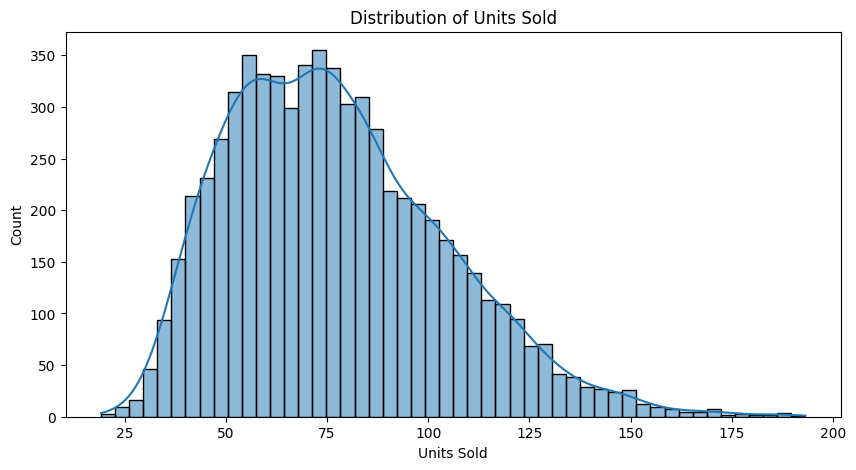

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["units_sold"],
    bins=50,
    kde=True
)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.show()

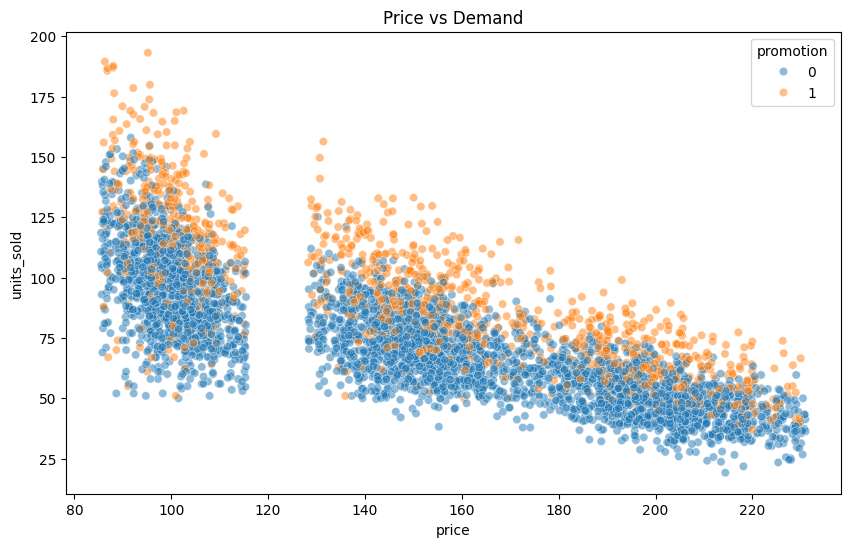

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x="price",
    y="units_sold",
    hue="promotion",
    alpha=0.5
)

plt.title("Price vs Demand")
plt.show()

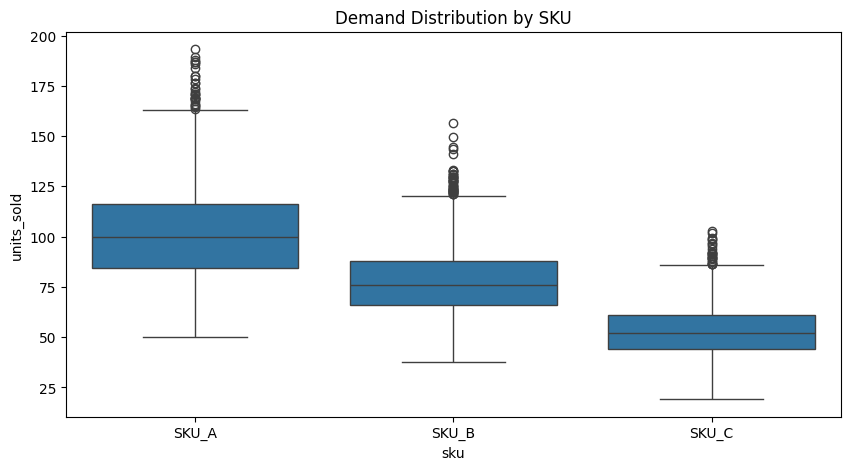

In [23]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="sku",
    y="units_sold"
)

plt.title("Demand Distribution by SKU")
plt.show()

In [24]:
df["revenue"] = df["price"] * df["units_sold"]

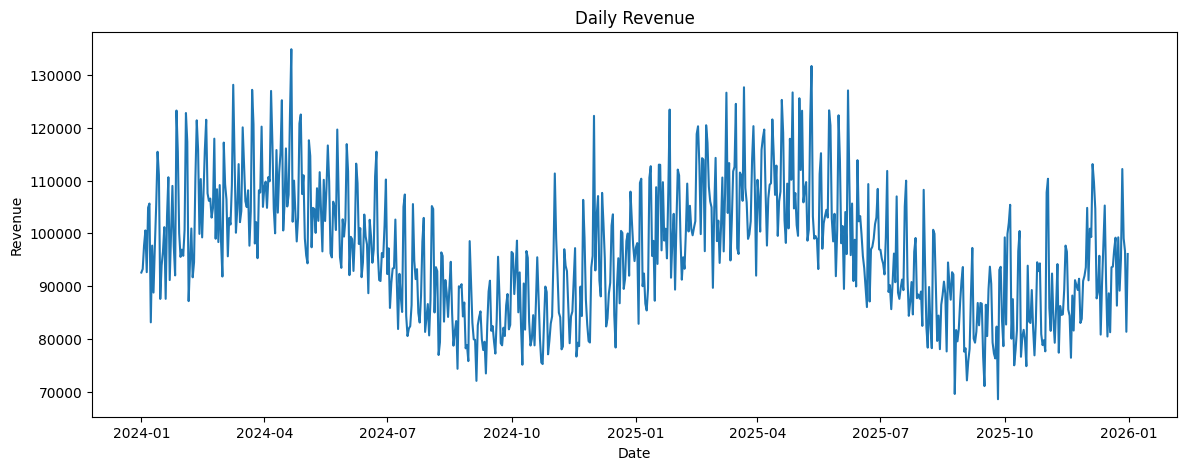

In [25]:
daily_revenue = (
    df.groupby("date")["revenue"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14,5))

plt.plot(
    daily_revenue["date"],
    daily_revenue["revenue"]
)

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

In [26]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_year"] = df["date"].dt.dayofyear

In [27]:
df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

In [28]:
df = df.sort_values(
    ["sku", "region", "date"]
)

df["lag_1"] = (
    df.groupby(["sku", "region"])["units_sold"]
      .shift(1)
)

df["lag_7"] = (
    df.groupby(["sku", "region"])["units_sold"]
      .shift(7)
)

df["lag_14"] = (
    df.groupby(["sku", "region"])["units_sold"]
      .shift(14)
)

In [41]:
## Filter by product and region
filter = (df['sku'] == 'SKU_A') & (df['region'] == 'North')

df.loc[filter,['units_sold', 'lag_1', 'lag_7']][1:10]

,units_sold,lag_1,lag_7
9,90.992943,105.217996,NaN
18,129.277110,90.992943,NaN
27,94.986116,129.277110,NaN
36,112.888306,94.986116,NaN
45,97.890328,112.888306,NaN
54,116.349127,97.890328,NaN
63,85.167704,116.349127,105.217996
72,114.000000,85.167704,90.992943
81,85.411050,114.000000,129.277110


In [42]:
df["rolling_7"] = (
    df.groupby(["sku", "region"])["units_sold"]
      .shift(1)
      .rolling(7)
      .mean()
)

df["rolling_30"] = (
    df.groupby(["sku", "region"])["units_sold"]
      .shift(1)
      .rolling(30)
      .mean()
)

In [43]:
df = df.dropna().reset_index(drop=True)

In [45]:
df_model = pd.get_dummies(
    df,
    columns=["sku", "region"],
    drop_first=False
)

In [46]:
features = [
    "price",
    "competitor_price",
    "promotion",
    "holiday",
    "marketing_spend",
    "temperature",
    "inventory",
    "month",
    "day_of_week",
    "week_of_year",
    "day_of_year",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_30"
]

# Add encoded categorical features
categorical_features = [
    col for col in df_model.columns
    if col.startswith("sku_") or col.startswith("region_")
]

features += categorical_features

X = df_model[features]
y = df_model["units_sold"]

In [47]:
X

,price,competitor_price,promotion,holiday,marketing_spend,temperature,inventory,month,day_of_week,week_of_year,...,lag_7,lag_14,rolling_7,rolling_30,sku_SKU_A,sku_SKU_B,sku_SKU_C,region_North,region_South,region_West
0,97.753472,95.843899,1,0,559.098741,28.473640,235,1,2,5,...,67.683175,102.999030,102.939844,102.450724,True,False,False,True,False,False
1,90.996841,98.347808,1,0,802.191757,28.841195,106,2,3,5,...,102.687023,83.424746,112.505298,103.431503,True,False,False,True,False,False
2,106.999507,110.616569,0,0,470.588987,32.237514,393,2,4,5,...,98.617546,108.835252,112.978580,103.931738,True,False,False,True,False,False
3,107.879794,111.208804,0,0,496.291077,28.316941,81,2,5,5,...,148.919007,107.000000,113.437608,103.016859,True,False,False,True,False,False
4,94.543591,100.916607,0,0,678.593719,31.046156,343,2,6,5,...,113.663909,113.807782,103.734893,102.550655,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6304,200.349380,213.754418,0,0,319.066143,24.848736,480,12,5,52,...,34.337512,49.194280,45.859403,45.999714,False,False,True,False,False,True
6305,206.014401,212.074041,0,0,345.363076,23.753154,412,12,6,52,...,55.298113,70.786565,49.067567,46.407435,False,False,True,False,False,True
6306,214.362447,221.923764,0,0,807.369668,27.792863,393,12,0,1,...,47.525465,31.395618,47.543502,46.683232,False,False,True,False,False,True
6307,206.162357,202.740250,0,0,399.351696,32.237225,140,12,1,1,...,41.547540,35.941509,47.970304,46.677114,False,False,True,False,False,True


In [48]:
split_date = "2025-07-01"

train = df_model[
    df_model["date"] < split_date
]

test = df_model[
    df_model["date"] >= split_date
]

X_train = train[features]
y_train = train["units_sold"]

X_test = test[features]
y_test = test["units_sold"]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (4653, 26)
Test : (1656, 26)


In [49]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

r2 = r2_score(
    y_test,
    pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4.699036521594233
RMSE: 5.942845115813975
R2  : 0.9422590759145864


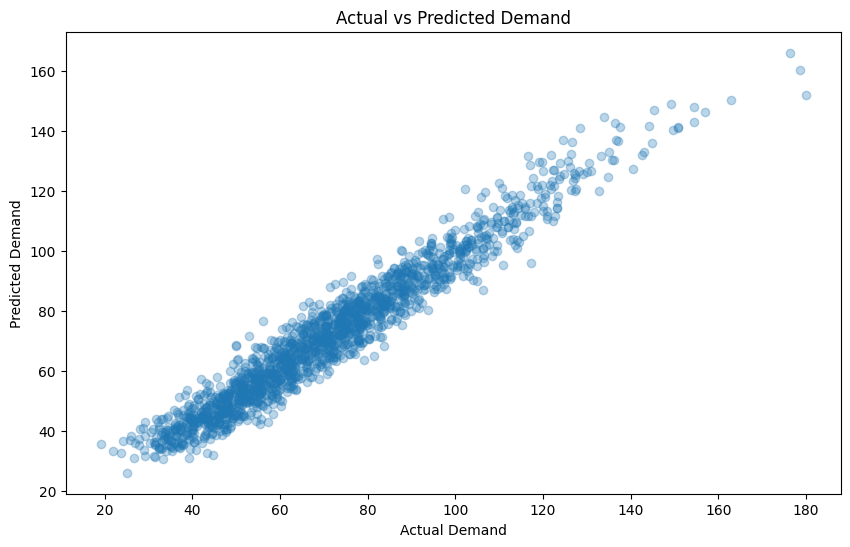

In [52]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.3
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.title("Actual vs Predicted Demand")

plt.show()

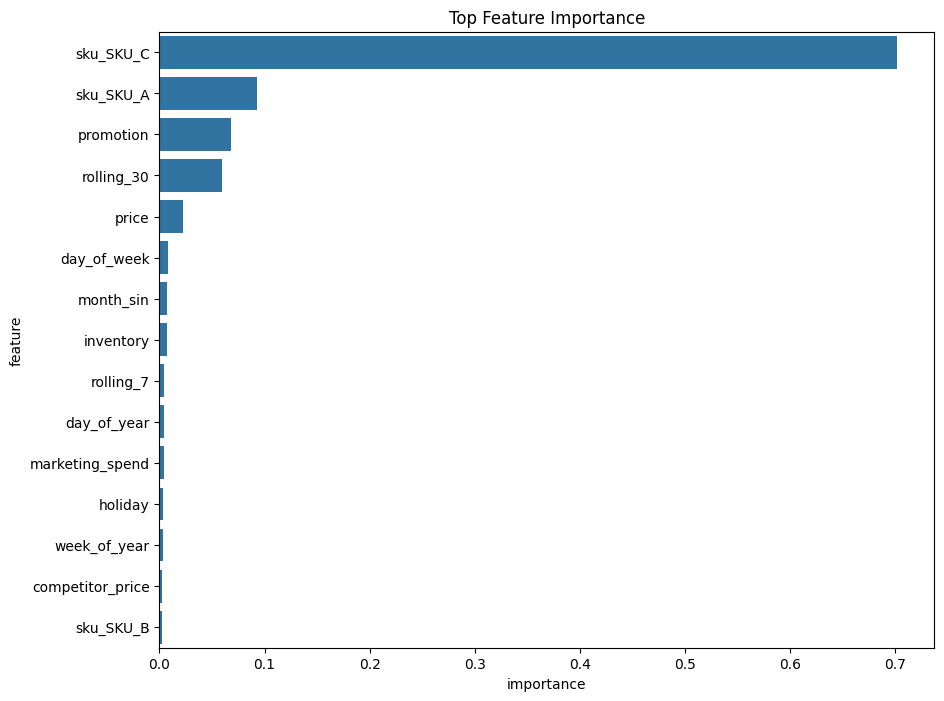

In [53]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Feature Importance")

plt.show()

In [54]:
def predict_demand_at_price(
    row,
    new_price,
    model,
    features
):

    scenario = row.copy()

    scenario["price"] = new_price

    scenario_df = pd.DataFrame([scenario])

    scenario_df = scenario_df[features]

    predicted_demand = model.predict(
        scenario_df
    )[0]

    return max(predicted_demand, 0)

In [55]:
scenario = test.iloc[100].copy()

print(
    "SKU:",
    scenario.get("sku_A"),
    scenario.get("sku_B"),
    scenario.get("sku_C")
)

print(
    "Current price:",
    scenario["price"]
)

print(
    "Actual demand:",
    scenario["units_sold"]
)

SKU: None None None
Current price: 96.58145443222206
Actual demand: 90.4651842369651


In [56]:
current_price = scenario["price"]

candidate_prices = np.arange(
    current_price * 0.8,
    current_price * 1.21,
    1
)

results = []

for price in candidate_prices:

    demand = predict_demand_at_price(
        scenario,
        price,
        model,
        features
    )

    revenue = price * demand

    results.append([
        price,
        demand,
        revenue
    ])

price_simulation = pd.DataFrame(
    results,
    columns=[
        "price",
        "predicted_demand",
        "predicted_revenue"
    ]
)

price_simulation.head()

,price,predicted_demand,predicted_revenue
0,77.265164,94.923775,7334.300978
1,78.265164,94.923775,7429.224753
2,79.265164,94.923775,7524.148528
3,80.265164,94.923775,7619.072302
4,81.265164,94.923775,7713.996077


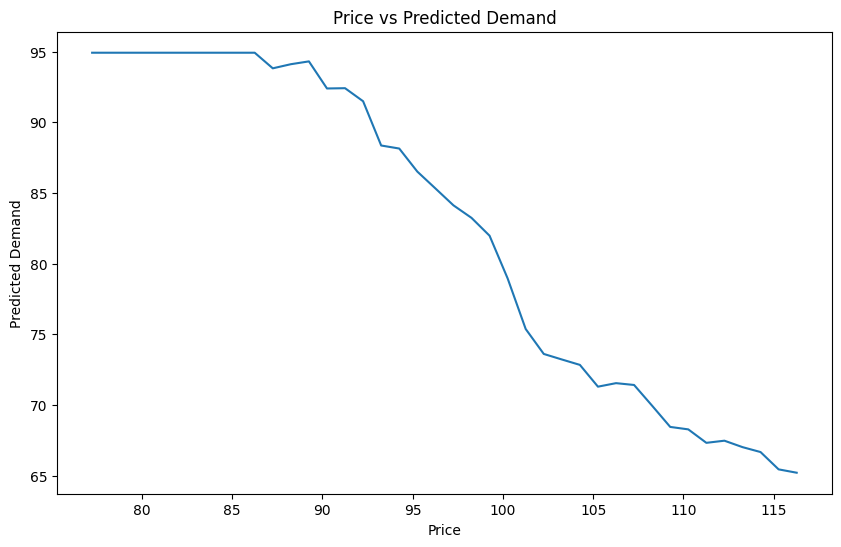

In [57]:
plt.figure(figsize=(10,6))

plt.plot(
    price_simulation["price"],
    price_simulation["predicted_demand"]
)

plt.xlabel("Price")
plt.ylabel("Predicted Demand")

plt.title("Price vs Predicted Demand")

plt.show()

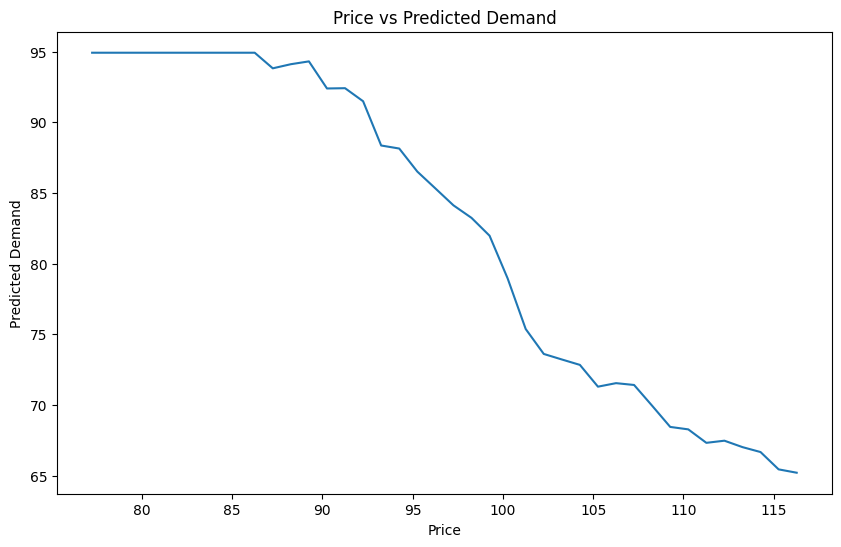

In [58]:
plt.figure(figsize=(10,6))

plt.plot(
    price_simulation["price"],
    price_simulation["predicted_demand"]
)

plt.xlabel("Price")
plt.ylabel("Predicted Demand")

plt.title("Price vs Predicted Demand")

plt.show()

In [59]:
best_row = price_simulation.loc[
    price_simulation["predicted_revenue"].idxmax()
]

print(
    "Current Price:",
    current_price
)

print(
    "Optimal Price:",
    best_row["price"]
)

print(
    "Predicted Demand:",
    best_row["predicted_demand"]
)

print(
    "Predicted Revenue:",
    best_row["predicted_revenue"]
)

Current Price: 96.58145443222206
Optimal Price: 92.26516354577765
Predicted Demand: 91.48954772949219
Predicted Revenue: 8441.298083990827


In [60]:
def objective(price):

    predicted_demand = predict_demand_at_price(
        scenario,
        price[0],
        model,
        features
    )

    revenue = price[0] * predicted_demand

    return -revenue

In [61]:
lower_bound = current_price * 0.80
upper_bound = current_price * 1.20

bounds = [
    (lower_bound, upper_bound)
]

In [62]:
optimization_result = minimize(
    objective,
    x0=[current_price],
    bounds=bounds,
    method="L-BFGS-B"
)

optimal_price = optimization_result.x[0]

print(
    "Current Price:",
    current_price
)

print(
    "Optimal Price:",
    optimal_price
)

Current Price: 96.58145443222206
Optimal Price: 97.54453897087016


In [63]:
optimal_demand = predict_demand_at_price(
    scenario,
    optimal_price,
    model,
    features
)

current_demand = predict_demand_at_price(
    scenario,
    current_price,
    model,
    features
)

current_revenue = (
    current_price * current_demand
)

optimal_revenue = (
    optimal_price * optimal_demand
)

print(
    f"Current price: ₹{current_price:.2f}"
)

print(
    f"Current predicted demand: {current_demand:.2f}"
)

print(
    f"Current predicted revenue: ₹{current_revenue:.2f}"
)

print()

print(
    f"Optimal price: ₹{optimal_price:.2f}"
)

print(
    f"Optimal predicted demand: {optimal_demand:.2f}"
)

print(
    f"Optimal predicted revenue: ₹{optimal_revenue:.2f}"
)

print()

print(
    f"Revenue improvement: "
    f"{(optimal_revenue/current_revenue - 1)*100:.2f}%"
)

Current price: ₹96.58
Current predicted demand: 84.49
Current predicted revenue: ₹8160.15

Optimal price: ₹97.54
Optimal predicted demand: 84.12
Optimal predicted revenue: ₹8205.77

Revenue improvement: 0.56%
